<a href="https://colab.research.google.com/github/glonsze/Sales-Analytics/blob/main/Sales_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/Mate_homework/Final_project/

/content/drive/MyDrive/Mate_homework/Final_project


In [ ]:
countries = pd.read_csv("countries.csv")
events = pd.read_csv("events.csv")
products = pd.read_csv("products.csv")

In [ ]:
countries.head() #дані про країни

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
events.head() #дані про продажі

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
products.head() #дані про товари

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


#products/events мають спільні колонки id продукта(products - внутрішній ключ, events має зовнішній ключ) countries/events  мають спільні колонки alpha-3/Country code

In [ ]:
events.isna().sum() / events.shape[0] * 100 #відсоток пропущених значень

,0
Order ID,0.000000
Order Date,0.000000
Ship Date,0.000000
Order Priority,0.000000
Country Code,6.165414
Product ID,0.000000
Sales Channel,0.000000
Units Sold,0.150376
Unit Price,0.000000
Unit Cost,0.000000


In [ ]:
events["Country Code"]= events['Country Code'].fillna("unknown") # частка невідомих значень суттєва, замінимо її на Unknown
events["Units Sold"]= events["Units Sold"].fillna(events["Units Sold"].median()) #заповнюємо пропущені значення середнім значенням

In [ ]:
events.isna().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0


In [ ]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1330 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1330 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [ ]:
events["Order Date"] = pd.to_datetime(events["Order Date"]) #order date та ship date змінюємо на тип даних datetime
events["Ship Date"] = pd.to_datetime(events["Ship Date"])

In [ ]:
events.columns = events.columns.str.lower().str.replace(" ", "_") #замість пробілу використаємо знак підкреслення. Саме такого стилю найменування змінних та функцій рекомендують притримуватись у Python.





In [ ]:
events['sales_channel'] = events['sales_channel'].str.lower()


In [ ]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1330 non-null   int64         
 1   order_date      1330 non-null   datetime64[ns]
 2   ship_date       1330 non-null   datetime64[ns]
 3   order_priority  1330 non-null   object        
 4   country_code    1330 non-null   object        
 5   product_id      1330 non-null   int64         
 6   sales_channel   1330 non-null   object        
 7   units_sold      1330 non-null   float64       
 8   unit_price      1330 non-null   float64       
 9   unit_cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 104.0+ KB


In [ ]:
products.isna().sum() / products.shape[1] # немає пропущених значень

,0
id,0.0
item_type,0.0


In [ ]:
#нема дублікатів
print(products.duplicated().sum())
print(events.duplicated().sum())
print(countries.duplicated().sum())

0
0
0


In [ ]:
#аномалії
print(events[events["order_date"] > events["ship_date"]].count()) #чи доставка була раніше ніж замовлення
print(events[events["units_sold"] < 0].count()) #чи продажу було менше за 0
 #Невідомі категорії
events[~events['product_id'].isin(products['id'])]

#аномалій немає

order_id          0
order_date        0
ship_date         0
order_priority    0
country_code      0
product_id        0
sales_channel     0
units_sold        0
unit_price        0
unit_cost         0
dtype: int64
order_id          0
order_date        0
ship_date         0
order_priority    0
country_code      0
product_id        0
sales_channel     0
units_sold        0
unit_price        0
unit_cost         0
dtype: int64


,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost


In [ ]:
events_products = pd.merge(events, products, left_on="product_id", right_on="id") #обєднуємо дві таблиці за product id
events_products.head()


,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,item_type
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,2103,Cereal
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,2103,Cereal
2,101025998,2014-07-18,2014-08-11,M,unknown,7940,online,4693.0,668.27,502.54,7940,Household
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,2455,Clothes
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,1270,Beverages


In [ ]:
store = pd.merge(events_products, countries, left_on="country_code", right_on="alpha-3") #обєднуємо дві таблиці за country code
store.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,item_type,name,alpha-2,alpha-3,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,online,2220.0,651.21,524.96,8681,Office Supplies,Slovakia,SK,SVK,Europe,Eastern Europe


In [ ]:
store = store.drop(columns=["alpha-2", "sub-region", "region"]) #прибираєм зайві колонки з якими не будемо працювати


In [ ]:
store.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,item_type,name,alpha-3
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,2103,Cereal,Norway,NOR
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,2103,Cereal,Serbia,SRB
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,2455,Clothes,Montenegro,MNE
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,1270,Beverages,Serbia,SRB
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,online,2220.0,651.21,524.96,8681,Office Supplies,Slovakia,SVK


In [ ]:
store = store.rename(columns={'name': 'country'}) #змінюю назву для колонок країн

In [ ]:
orders = store["order_id"].count()#кількість замовлень
orders

np.int64(1248)

In [ ]:
store["profit"] = (store['unit_price'] - store['unit_cost']) * store["units_sold"] # дохід
store["profit"] = store["profit"].round(2)
print(f"profit: {store['profit'].sum().round(2)}");
store["cost"] = store['unit_cost'] * store['units_sold'] #витрати
print(f"cost: {store['cost'].sum()}")
store["revenue"] = store["units_sold"] * store["unit_price"] #дохід від продаж
print(f"revenue: {store['revenue'].sum()}")

profit: 474117209.18
cost: 1127365514.52
revenue: 1601482723.7


In [ ]:
sum(store["revenue"] - store["cost"]) == sum(store["profit"]) #перевірка чи співпадають значення

True

In [ ]:
store.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,item_type,country,alpha-3,profit,cost,revenue
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,2103,Cereal,Norway,NOR,57583.50,76121.50,133705.00
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,2103,Cereal,Serbia,SRB,176559.87,233400.23,409960.10
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,2455,Clothes,Montenegro,MNE,85998.24,41968.64,127966.88
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,1270,Beverages,Serbia,SRB,119767.68,243129.92,362897.60
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,online,2220.0,651.21,524.96,8681,Office Supplies,Slovakia,SVK,280275.00,1165411.20,1445686.20


In [ ]:
unique_countries = store["country"].nunique() #кількість охоплених країн
unique_countries

45

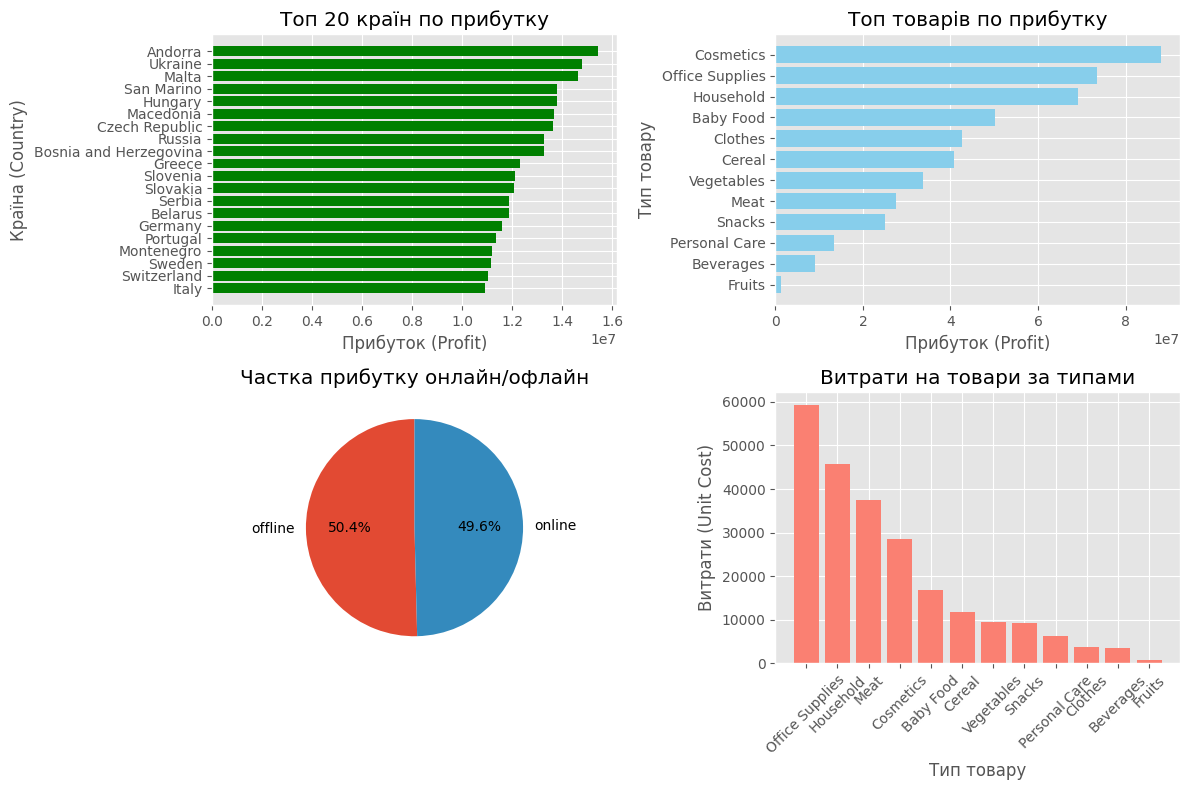

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

#країни по прибутку

country_profits = store.groupby("country")["profit"].sum().sort_values(ascending=False).head(20)

ax[0, 0].barh(country_profits.index, country_profits.values, color="green")
ax[0, 0].set_title("Топ 20 країн по прибутку")
ax[0, 0].set_xlabel("Прибуток (Profit)")
ax[0, 0].set_ylabel("Країна (Country)")
ax[0, 0].invert_yaxis()

#Популярність товарів
products_profits = store.groupby("item_type")["profit"].sum().sort_values(ascending=False)

ax[0, 1].barh(products_profits.index, products_profits.values, color="skyblue")
ax[0, 1].set_title("Топ товарів по прибутку")
ax[0, 1].set_xlabel("Прибуток (Profit)")
ax[0, 1].set_ylabel("Тип товару")
ax[0, 1].invert_yaxis()

#Замовлення по каналів продажу
offline_online_profits = store.groupby("sales_channel")["profit"].sum().sort_values(ascending=False)
ax[1, 0].pie(offline_online_profits.values, labels=offline_online_profits.index, autopct='%1.1f%%', startangle=90)
ax[1, 0].set_title("Частка прибутку онлайн/офлайн")

#витрати на товари
products_costs = store.groupby("item_type")["unit_cost"].sum().sort_values(ascending=False)

ax[1, 1].bar(products_costs.index, products_costs.values, color="salmon")
ax[1, 1].set_title("Витрати на товари за типами")
ax[1, 1].set_xlabel("Тип товару")
ax[1, 1].set_ylabel("Витрати (Unit Cost)")

ax[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()

plt.show()

In [ ]:
store.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,item_type,country,alpha-3,profit,cost,revenue
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,2103,Cereal,Norway,NOR,57583.50,76121.50,133705.00
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,2103,Cereal,Serbia,SRB,176559.87,233400.23,409960.10
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,2455,Clothes,Montenegro,MNE,85998.24,41968.64,127966.88
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,1270,Beverages,Serbia,SRB,119767.68,243129.92,362897.60
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,online,2220.0,651.21,524.96,8681,Office Supplies,Slovakia,SVK,280275.00,1165411.20,1445686.20


In [ ]:
store["days"] = store["order_date"].dt.day_name() #знаходжу дні тижня за датою

In [ ]:
store

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,id,item_type,country,alpha-3,profit,cost,revenue,days
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,2103,Cereal,Norway,NOR,57583.50,76121.50,133705.00,Wednesday
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,2103,Cereal,Serbia,SRB,176559.87,233400.23,409960.10,Thursday
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,2455,Clothes,Montenegro,MNE,85998.24,41968.64,127966.88,Saturday
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,1270,Beverages,Serbia,SRB,119767.68,243129.92,362897.60,Saturday
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,online,2220.0,651.21,524.96,8681,Office Supplies,Slovakia,SVK,280275.00,1165411.20,1445686.20,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243,994504153,2017-01-10,2017-01-13,M,SWE,4594,online,4734.0,9.33,6.92,4594,Fruits,Sweden,SWE,11408.94,32759.28,44168.22,Tuesday
1244,994978797,2014-12-05,2015-01-02,H,ITA,1270,offline,5192.0,47.45,31.79,1270,Beverages,Italy,ITA,81306.72,165053.68,246360.40,Friday
1245,996754205,2010-09-20,2010-09-22,L,RUS,7331,offline,574.0,255.28,159.42,7331,Baby Food,Russia,RUS,55023.64,91507.08,146530.72,Monday
1246,998043382,2010-06-15,2010-07-03,H,MLT,8293,online,2070.0,437.20,263.33,8293,Cosmetics,Malta,MLT,359910.90,545093.10,905004.00,Tuesday


In [ ]:
store['ship_time'] = (store['ship_date'] - store['order_date']).dt.days #знаходжу час від замовлення до доставки

In [ ]:
# Перевірка на від'ємні значення
print(f"Від'ємних значень ship_time: {(store['ship_time'] < 0).sum()}")

Від'ємних значень ship_time: 0


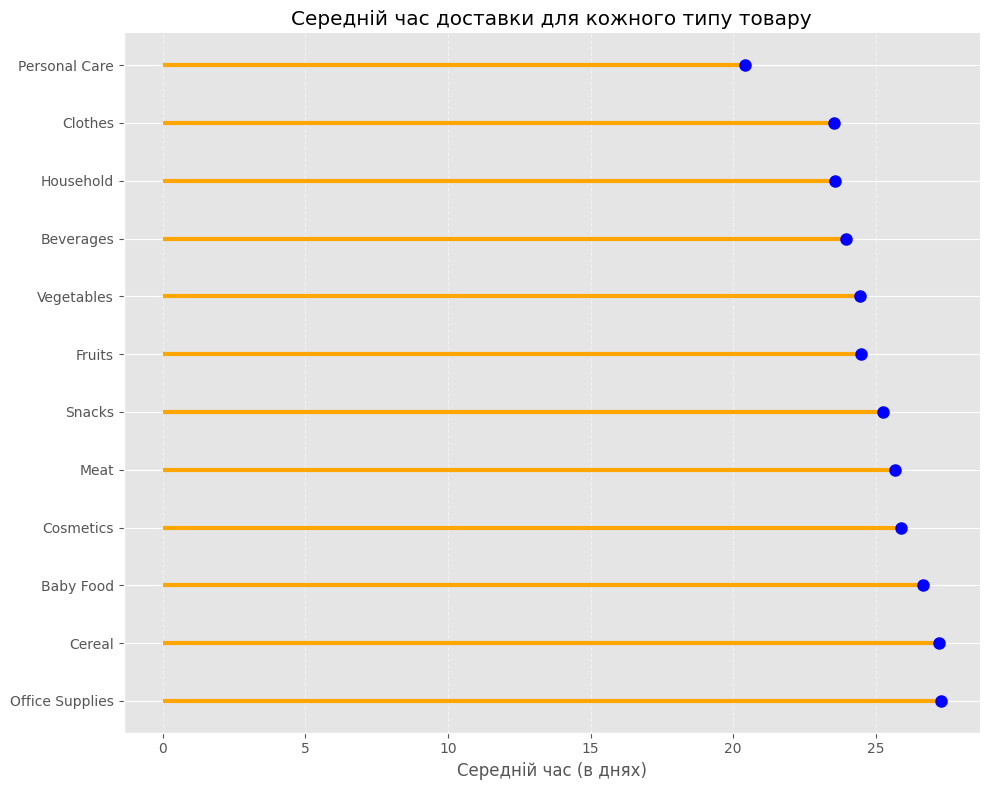

In [ ]:

ship_items = store.groupby("item_type")["ship_time"].mean().sort_values() #знаходжу середній час від замовлення до доставки

plt.figure(figsize=(10, 8))
plt.hlines(y=ship_items.index[::-1], xmin=0, xmax=ship_items.values[::-1], color='orange', linewidth=3)
plt.plot(ship_items.values[::-1], ship_items.index[::-1], "o", color='blue', markersize=8)

plt.xlabel('Середній час (в днях)')
plt.title('Середній час доставки для кожного типу товару')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_5259/740007897.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=store, x='order_priority', y='ship_time',


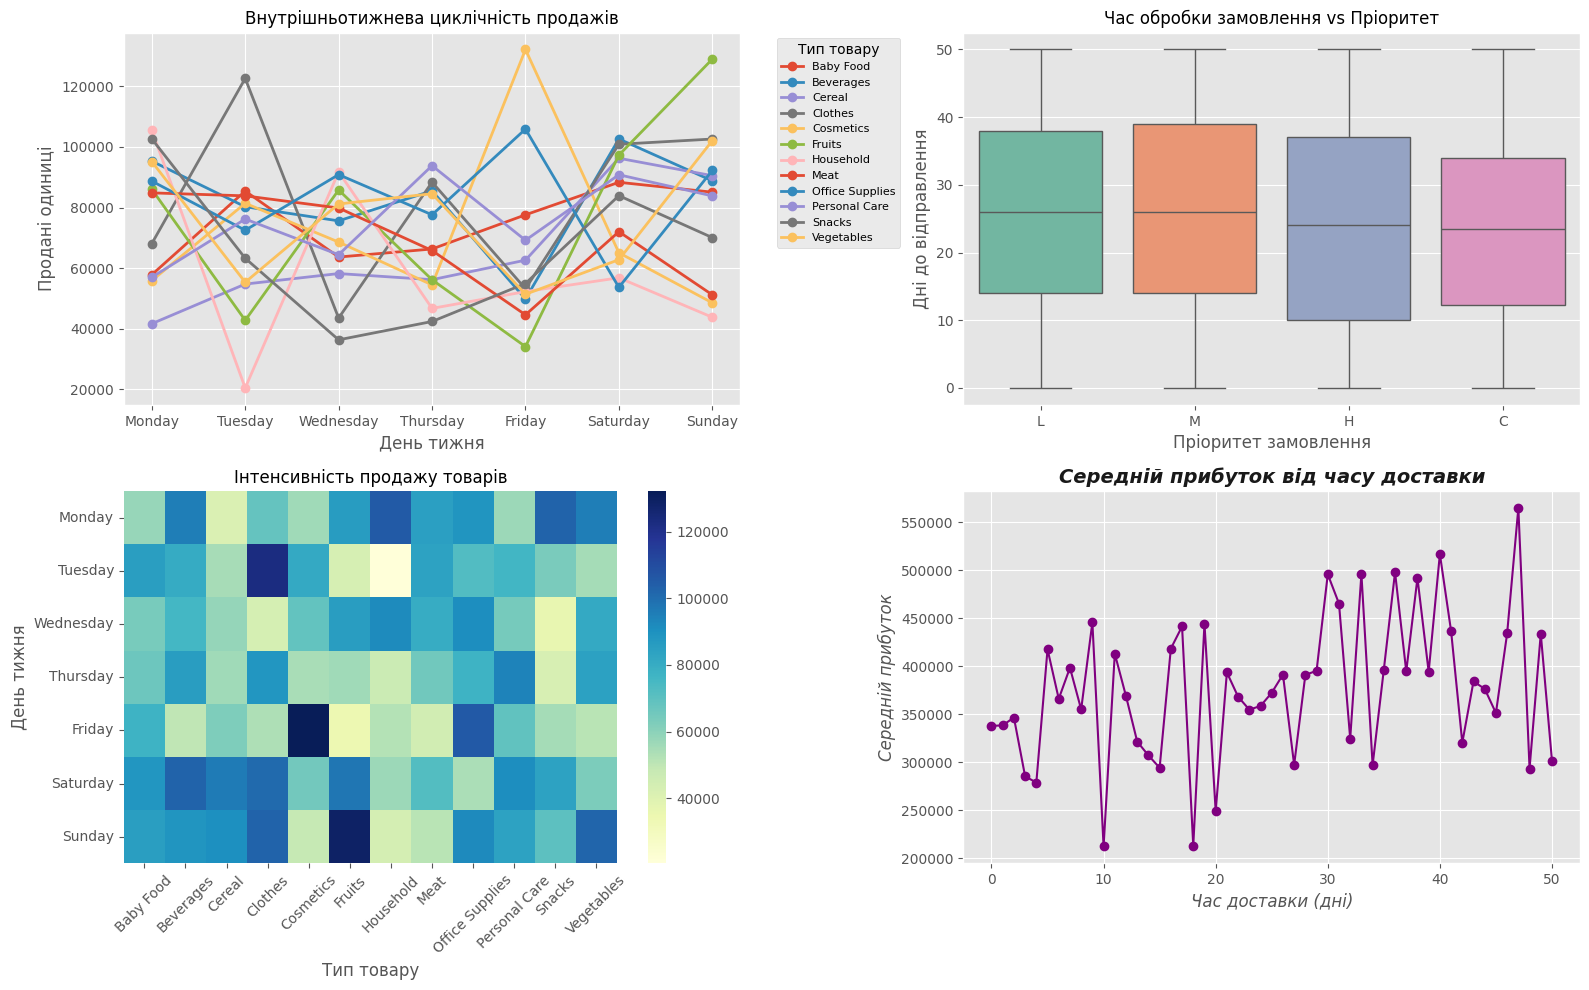

In [ ]:

plt.style.use("ggplot")


fig, ax = plt.subplots(2, 2, figsize=(16, 10))
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Групуємо загальну кількість проданих товарів за днями тижня та типами товарів
weekly_trends = store.groupby(['days', 'item_type'])['units_sold'].sum().unstack()
weekly_trends = weekly_trends.reindex(days_order)

weekly_trends.plot(kind='line', marker='o', linewidth=2, ax=ax[0, 0])
ax[0, 0].set_title("Внутрішньотижнева циклічність продажів", fontsize=12)
ax[0, 0].set_xlabel("День тижня")
ax[0, 0].set_ylabel("Продані одиниці")

ax[0, 0].legend(title="Тип товару", fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

#час обробки замовлення в залежності від пріоритету
sns.boxplot(data=store, x='order_priority', y='ship_time',
            order=['L', 'M', 'H', 'C'], palette="Set2", ax=ax[0, 1])
ax[0, 1].set_title("Час обробки замовлення vs Пріоритет", fontsize=12)
ax[0, 1].set_xlabel("Пріоритет замовлення")
ax[0, 1].set_ylabel("Дні до відправлення")


pivot_days = store.pivot_table(index='days', columns='item_type', values='units_sold', aggfunc='sum')
pivot_days = pivot_days.reindex(days_order)


#Інтенсивність продажу товарів по днях тижня
sns.heatmap(pivot_days, cmap="YlGnBu", annot=False, ax=ax[1, 0])
ax[1, 0].set_title("Інтенсивність продажу товарів", fontsize=12)
ax[1, 0].set_ylabel("День тижня")
ax[1, 0].set_xlabel("Тип товару")
ax[1, 0].tick_params(axis='x', rotation=45)

#прибуток залежно від часу доставки
agg = store.groupby("ship_time")["profit"].mean()
agg.plot(kind="line", marker="o", color="purple", ax=ax[1, 1])
ax[1, 1].set_title(
    "Середній прибуток від часу доставки",
    fontsize=14,
    fontweight="bold",
    fontstyle="italic",
    color="black",
    alpha=0.9
)
ax[1, 1].set_xlabel("Час доставки (дні)", fontsize=12, fontstyle="italic")
ax[1, 1].set_ylabel("Середній прибуток", fontsize=12, fontstyle="italic")

plt.tight_layout()
plt.show()

## Бізнес-висновки

На основі проведеного аналізу даних можна зробити наступні висновки:

1.  **Загальна прибутковість:** Компанія має значний загальний прибуток у розмірі приблизно **474.18 мільйона доларів**.

2.  **Топ-категорії товарів за прибутком:**
    *   **Cosmetics** є найбільш прибутковою категорією.
    *   **Office Supplies** та **Household** також входять до трійки лідерів.
    *   **Beverages** та **Fruits** є найменш прибутковими категоріями, можливо, потребують перегляду стратегії ціноутворення або маркетингу.

3.  **Ефективність каналів продажів:**
    *   **Офлайн-продажі** приносять трохи більший прибуток (приблизно 238.92 мільйона) порівняно з **онлайн-продажами** (приблизно 235.20 мільйона). Це свідчить про важливість обох каналів і, можливо, покращити онлайн канал.

4.  **Час обробки та доставки:**
    *   **Personal Care** та **Clothes** мають найшвидший середній час доставки.
    *   **Office Supplies** та **Cereal** мають найдовший середній час доставки. Можливо, варто дослідити логістичні процеси для цих категорій.
    *   **Пріоритет замовлення** має чіткий вплив на час доставки: замовлення з високим пріоритетом (H - High, C - Critical) обробляються швидше.
    *   Залежність середнього прибутку від часу доставки не є лінійною. Існують пікові значення прибутку при певних термінах доставки, що може вказувати на оптимальні терміни для максимізації прибутку.

6.  **Географічна розширеність:** Компанія охоплює 45 країн, при цьому **Андорра, Україна та Мальта** є лідерами за прибутком.

## Бізнес-рекомендації
  *
    *   **Зосередитися на високоприбуткових категоріях:** Продовжувати активно розвивати та просувати **Cosmetics, Office Supplies** та **Household**, оскільки вони є найприбутковіші товари із всіх категорій.
    *   **Обрати іншу стратегію для низькоприбуткових товарів:** Для **Beverages** та **Fruits** слід проаналізувати можливість підвищення цін, зниження витрат, проведення маркетингових акцій

    *   **Дослідити та покращити процеси доставки для 'Office Supplies' та 'Cereal':** Оскільки ці категорії мають найдовший середній час доставки, необхідно виявити слабкі місця в логістиці